# Loan Approval Prediction using Python

This notebook follows the steps of the Simplilearn *Loan Approval Prediction* walkthrough, applied to the Cognilend dataset (`loan_applications_raw.csv`).

The video's order is kept: import libraries → load data → `head` / `info` / `isnull` → log transforms and histograms → fill missing values → count plots → train/test split → `LabelEncoder` → `StandardScaler` → Random Forest, Naive Bayes, Decision Tree, KNN → compare accuracy.

Where the video's code doesn't fit this dataset, or has a bug, the cell is changed and a **Change from video** note explains why:
- The video's dataset was nearly clean, but ours has deliberate data-quality problems (see `report.md` §2). An extra cleaning step is added before the analysis.
- The video called `fit_transform` on the **test** set for both `LabelEncoder` and `StandardScaler`. That leaks test data into the model and can give the same category different codes in train and test. Here the encoders are fitted on the training set and only `transform` is applied to the test set.
- `Gender` and `Marital_Status` are plotted but not used as model inputs (report §4.2, step 0: RBI Fair Practices Code).

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Import the dataset

In [2]:
df = pd.read_csv('loan_applications_raw.csv')
df.head()

,Loan_ID,Age,Gender,Marital_Status,Dependents,Employment_Type,Work_Experience,Monthly_Income,Coapplicant_Income,Existing_EMI,CIBIL_Score,Loan_Type,Loan_Amount,Loan_Tenure,Collateral_Value,Property_Area,Loan_Status
0,LN2025102971,40.0,Transgender,Married,0,salaried,18.0,45800.0,NaN,1900.0,821.0,Home Loan,1440000.0,240.0,2080000.0,Rural,Approved
1,LN2025107793,46.0,Male,Married,2,Self-Employed Non-Professional,19.0,38400.0,NaN,0.0,748.0,Personal Loan,280000.0,36.0,NaN,Semi-Urban,Approved
2,LN2025102488,24.0,Male,Single,0,Salaried,4.0,39400.0,23600.0,0.0,851.0,Home Loan,2690000.0,240.0,3710000.0,Rural,Approved
3,LN2025106297,34.0,Male,Married,0,Self-Employed Non-Professional,10.0,51000.0,NaN,0.0,747.0,Home Loan,2180000.0,240.0,2940000.0,Urban,Approved
4,LN2025108470,23.0,Male,Single,0,Salaried,0.0,43500.0,NaN,0.0,801.0,Personal Loan,460000.0,36.0,NaN,Semi-Urban,Rejected


In [3]:
df.tail()

,Loan_ID,Age,Gender,Marital_Status,Dependents,Employment_Type,Work_Experience,Monthly_Income,Coapplicant_Income,Existing_EMI,CIBIL_Score,Loan_Type,Loan_Amount,Loan_Tenure,Collateral_Value,Property_Area,Loan_Status
9995,LN2025107524,35.0,Male,Married,1,Salaried,14.0,-43300.0,NaN,0.0,723.0,Personal Loan,310000.0,36.0,NaN,Urban,Approved
9996,LN2025107331,29.0,Female,Single,0,Self-Employed Professional,0.0,51500.0,NaN,7200.0,659.0,Vehicle Loan,300000.0,48.0,360000.0,urban,Rejected
9997,LN2025101485,43.0,Male,Widowed,NaN,salaried,20.0,51400.0,45600.0,0.0,568.0,HL,3350000.0,180.0,4510000.0,Urban,Rejected
9998,LN2025106804,57.0,Transgender,Married,2,Self-Employed Professional,28.0,244000.0,NaN,0.0,768.0,Business Loan,4620000.0,36.0,7940000.0,Urban,Approved
9999,LN2025107906,46.0,Female,Married,NaN,Self-Employed Non-Professional,22.0,168400.0,32700.0,94100.0,712.0,Vehicle Loan,1660000.0,60.0,2050000.0,NaN,Approved


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             10000 non-null  str    
 1   Age                 10000 non-null  float64
 2   Gender              9821 non-null   str    
 3   Marital_Status      9882 non-null   str    
 4   Dependents          9760 non-null   str    
 5   Employment_Type     10000 non-null  str    
 6   Work_Experience     9699 non-null   float64
 7   Monthly_Income      9901 non-null   float64
 8   Coapplicant_Income  3213 non-null   float64
 9   Existing_EMI        9748 non-null   float64
 10  CIBIL_Score         9901 non-null   float64
 11  Loan_Type           10000 non-null  str    
 12  Loan_Amount         9848 non-null   str    
 13  Loan_Tenure         9819 non-null   float64
 14  Collateral_Value    5750 non-null   float64
 15  Property_Area       9851 non-null   str    
 16  Loan_Status     

## 3. Missing values

In [5]:
df.isnull().sum()

Loan_ID                  0
Age                      0
Gender                 179
Marital_Status         118
Dependents             240
Employment_Type          0
Work_Experience        301
Monthly_Income          99
Coapplicant_Income    6787
Existing_EMI           252
CIBIL_Score             99
Loan_Type                0
Loan_Amount            152
Loan_Tenure            181
Collateral_Value      4250
Property_Area          149
Loan_Status             18
dtype: int64

## 3a. Clean the raw data (extra step, not in the video)

Without this the video's steps would not run on our file: `Loan_Amount` is text such as `"Rs. 27,90,000"`, `Gender` has 25 spellings for 3 values, and some ages are 999. These steps follow `report.md` §3.1–3.6.

In [6]:
text_cols = ['Gender', 'Marital_Status', 'Dependents', 'Employment_Type',
             'Loan_Type', 'Loan_Amount', 'Property_Area', 'Loan_Status']

# 1. Strip leading/trailing whitespace ('Male ' -> 'Male'); empty strings become NaN
for c in text_cols:
    df[c] = df[c].str.strip().replace('', np.nan)

# 2. Exact duplicate rows (double-submitted applications)
print('Duplicate rows removed:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# 3. Rows with no recorded decision: the label is never imputed
print('Rows with missing Loan_Status removed:', df['Loan_Status'].isnull().sum())
df = df.dropna(subset=['Loan_Status']).reset_index(drop=True)

# 4. Standardise category spellings
category_maps = {
    'Gender': {'m': 'Male', 'male': 'Male', 'f': 'Female', 'female': 'Female',
               'tg': 'Transgender', 'transgender': 'Transgender'},
    'Marital_Status': {'married': 'Married', 'single': 'Single', 'unmarried': 'Single',
                       'divorced': 'Divorced', 'widowed': 'Widowed'},
    'Employment_Type': {'salaried': 'Salaried', 'service': 'Salaried',
                        'sep': 'SEP', 'self employed professional': 'SEP',
                        'self-employed professional': 'SEP',
                        'senp': 'SENP', 'self-employed non-professional': 'SENP',
                        'self employed business': 'SENP', 'business owner': 'SENP'},
    'Loan_Type': {'hl': 'Home', 'home loan': 'Home', 'housing loan': 'Home',
                  'auto loan': 'Vehicle', 'car loan': 'Vehicle', 'vehicle loan': 'Vehicle',
                  'pl': 'Personal', 'personal': 'Personal', 'personal loan': 'Personal',
                  'bl': 'Business', 'business loan': 'Business', 'msme loan': 'Business'},
    'Property_Area': {'urban': 'Urban', 'semiurban': 'Semi-Urban', 'semi urban': 'Semi-Urban',
                      'semi-urban': 'Semi-Urban', 'rural': 'Rural'},
    'Loan_Status': {'approved': 'Approved', 'rejected': 'Rejected'},
}
for c, mapping in category_maps.items():
    mapped = df[c].str.lower().map(mapping)
    assert mapped.notna().sum() == df[c].notna().sum(), f'unmapped value in {c}'
    df[c] = mapped

# 5. Fix data types
df['Loan_Amount'] = pd.to_numeric(df['Loan_Amount'].str.replace(r'Rs\.|,|\s', '', regex=True))
df['Dependents'] = pd.to_numeric(df['Dependents'].replace('3+', '3'))   # '3 or more' capped at 3

# 6. Domain validity rules: recover the value when the error is obvious, otherwise set NaN
df.loc[~df['Age'].between(18, 75), 'Age'] = np.nan                       # ages like -30, 999
df['Monthly_Income'] = df['Monthly_Income'].abs()                        # sign error
df.loc[df['Monthly_Income'] == 0, 'Monthly_Income'] = np.nan
bad_cibil = df['CIBIL_Score'].notna() & (df['CIBIL_Score'] != -1) & ~df['CIBIL_Score'].between(300, 900)
df.loc[bad_cibil, 'CIBIL_Score'] = np.nan                                # -1 = new to credit, kept
exp = df['Work_Experience']
df.loc[(exp < 0) | (exp > 50) | (exp > df['Age'] - 18), 'Work_Experience'] = np.nan
in_years = (df['Loan_Type'] == 'Home') & (df['Loan_Tenure'] <= 30)      # home-loan tenure keyed in years
df.loc[in_years, 'Loan_Tenure'] *= 12

print('Shape after cleaning:', df.shape)
df['Gender'].value_counts(dropna=False)

Duplicate rows removed: 135
Rows with missing Loan_Status removed: 18
Shape after cleaning: (9847, 17)


Gender
Male           6880
Female         2733
NaN             176
Transgender      58
Name: count, dtype: int64

## 4. Loan amount log and histogram

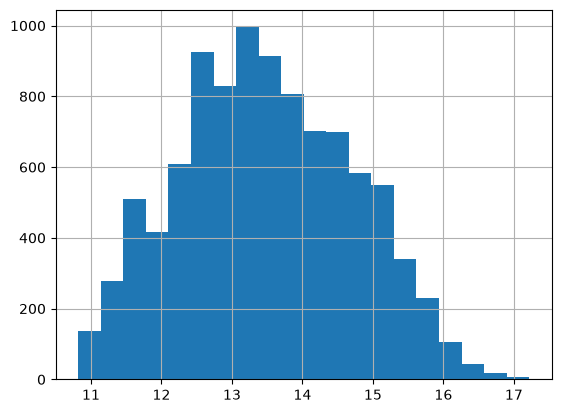

In [7]:
df['Loan_Amount_log'] = np.log(df['Loan_Amount'])
df['Loan_Amount_log'].hist(bins=20)
plt.show()

In [8]:
df.isnull().sum()

Loan_ID                  0
Age                     28
Gender                 176
Marital_Status         118
Dependents             236
Employment_Type          0
Work_Experience        341
Monthly_Income         107
Coapplicant_Income    6685
Existing_EMI           247
CIBIL_Score            131
Loan_Type                0
Loan_Amount            148
Loan_Tenure            178
Collateral_Value      4181
Property_Area          148
Loan_Status              0
Loan_Amount_log        148
dtype: int64

## 5. Total income log and histogram

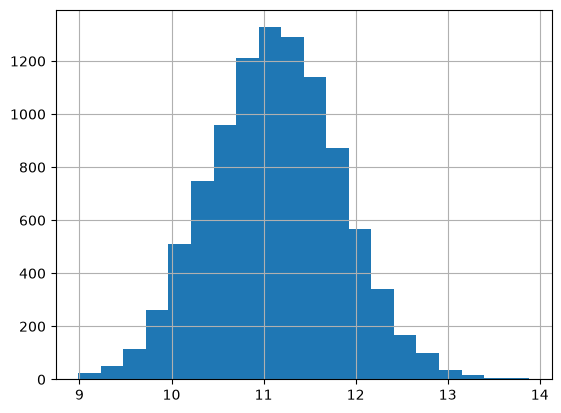

In [9]:
# Change from video: a blank Coapplicant_Income means 'no earning co-applicant',
# so it is filled with 0 (structural missingness, report §3.7)
df['Coapplicant_Income'] = df['Coapplicant_Income'].fillna(0)

df['Total_Income'] = df['Monthly_Income'] + df['Coapplicant_Income']
df['Total_Income_log'] = np.log(df['Total_Income'])
df['Total_Income_log'].hist(bins=20)
plt.show()

## 6. Fill the missing values

**Change from video:** the video filled every categorical column with the mode and `LoanAmount` with the mean. Here:
- Protected attributes get `'Unknown'`, because a person's gender is never guessed.
- Group-wise values are used where one global value would be wrong. For example, the global mode of tenure is 36 months, which makes no sense for a home loan.
- Medians are used instead of means because the money columns are heavily skewed.

In [10]:
df['Gender'] = df['Gender'].fillna('Unknown')
df['Marital_Status'] = df['Marital_Status'].fillna('Unknown')
df['Property_Area'] = df['Property_Area'].fillna(df['Property_Area'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(
    df.groupby('Marital_Status')['Dependents'].transform(lambda s: s.mode()[0]))

df['Age'] = df['Age'].fillna(df.groupby('Employment_Type')['Age'].transform('median'))
df['Monthly_Income'] = df['Monthly_Income'].fillna(
    df.groupby(['Employment_Type', 'Property_Area'])['Monthly_Income'].transform('median'))
df['Work_Experience'] = df['Work_Experience'].fillna(
    df.groupby('Employment_Type')['Work_Experience'].transform('median'))
df['Work_Experience'] = df['Work_Experience'].clip(lower=0, upper=df['Age'] - 18)
df['Existing_EMI'] = df['Existing_EMI'].fillna(df['Existing_EMI'].median())
scored = df['CIBIL_Score'] != -1
df['CIBIL_Score'] = df['CIBIL_Score'].fillna(df.loc[scored, 'CIBIL_Score'].median())
df['Loan_Amount'] = df['Loan_Amount'].fillna(df.groupby('Loan_Type')['Loan_Amount'].transform('median'))
df['Loan_Tenure'] = df['Loan_Tenure'].fillna(
    df.groupby('Loan_Type')['Loan_Tenure'].transform(lambda s: s.mode()[0]))

# Collateral: unsecured products -> 0; secured products -> back-fill from the median LTV of that type
unsecured = df['Loan_Type'].isin(['Personal', 'Business'])
df.loc[unsecured, 'Collateral_Value'] = df.loc[unsecured, 'Collateral_Value'].fillna(0)
median_ltv = (df['Loan_Amount'] / df['Collateral_Value']).where(~unsecured).groupby(df['Loan_Type']).median()
df['Collateral_Value'] = df['Collateral_Value'].fillna(df['Loan_Amount'] / df['Loan_Type'].map(median_ltv))

# Recompute the derived columns now that their inputs are filled
df['Loan_Amount_log'] = np.log(df['Loan_Amount'])
df['Total_Income'] = df['Monthly_Income'] + df['Coapplicant_Income']
df['Total_Income_log'] = np.log(df['Total_Income'])

df.isnull().sum()

Loan_ID               0
Age                   0
Gender                0
Marital_Status        0
Dependents            0
Employment_Type       0
Work_Experience       0
Monthly_Income        0
Coapplicant_Income    0
Existing_EMI          0
CIBIL_Score           0
Loan_Type             0
Loan_Amount           0
Loan_Tenure           0
Collateral_Value      0
Property_Area         0
Loan_Status           0
Loan_Amount_log       0
Total_Income          0
Total_Income_log      0
dtype: int64

## 7. Percent of missing values

In [11]:
for col in ['Gender', 'Marital_Status', 'Dependents', 'Employment_Type', 'Loan_Amount', 'CIBIL_Score']:
    print('Percent of missing %-16s is %.2f%%' % (col, df[col].isnull().sum() / df.shape[0] * 100))

Percent of missing Gender           is 0.00%
Percent of missing Marital_Status   is 0.00%
Percent of missing Dependents       is 0.00%
Percent of missing Employment_Type  is 0.00%
Percent of missing Loan_Amount      is 0.00%
Percent of missing CIBIL_Score      is 0.00%


## 8. Number of people who take a loan, by group

**Change from video:** `hue='Loan_Status'` is added so each bar is split into approved and rejected, which shows how the group relates to the decision. The video's *Loan Amount* count plot (one bar per distinct amount) is replaced by *Loan Type*. *Credit History* is replaced by its equivalent here, CIBIL band.

Number of people who take loan as group by gender:
Gender
Male           6880
Female         2733
Unknown         176
Transgender      58
Name: count, dtype: int64


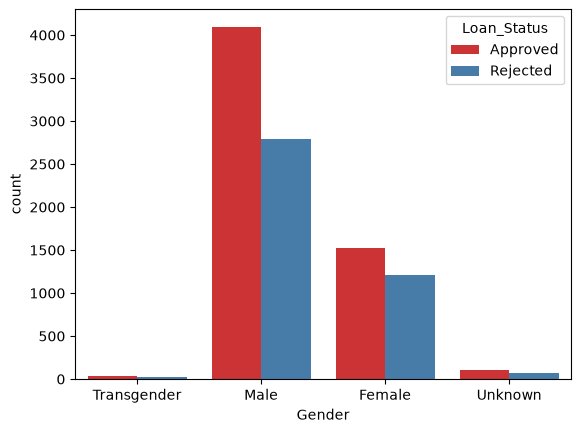

In [12]:
print('Number of people who take loan as group by gender:')
print(df['Gender'].value_counts())
sns.countplot(x='Gender', hue='Loan_Status', data=df, palette='Set1')
plt.show()

Number of people who take loan as group by marital status:
Marital_Status
Married     7300
Single      2249
Unknown      118
Divorced      94
Widowed       86
Name: count, dtype: int64


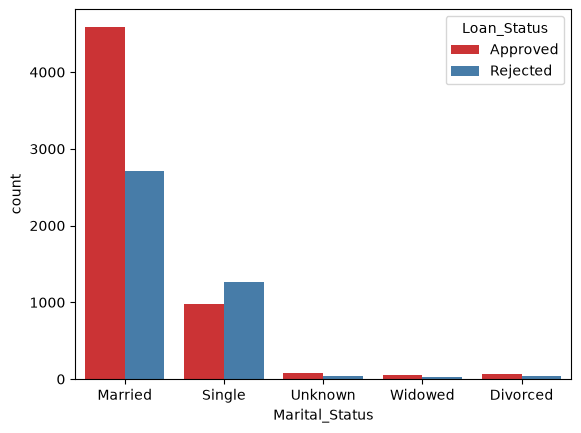

In [13]:
print('Number of people who take loan as group by marital status:')
print(df['Marital_Status'].value_counts())
sns.countplot(x='Marital_Status', hue='Loan_Status', data=df, palette='Set1')
plt.show()

Number of people who take loan as group by dependents:
Dependents
0.0    2769
1.0    2637
2.0    2622
3.0    1819
Name: count, dtype: int64


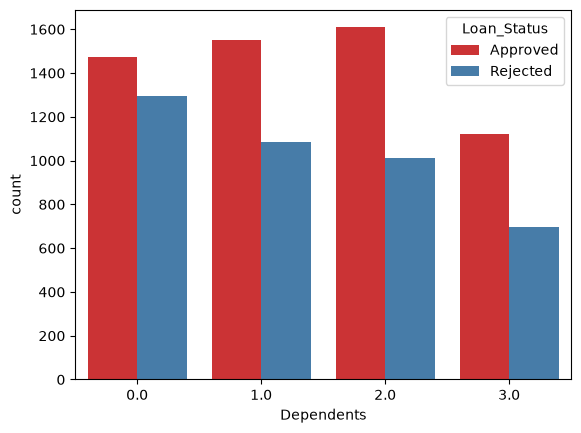

In [14]:
print('Number of people who take loan as group by dependents:')
print(df['Dependents'].value_counts())
sns.countplot(x='Dependents', hue='Loan_Status', data=df, palette='Set1')
plt.show()

Number of people who take loan as group by employment type:
Employment_Type
Salaried    5951
SENP        2406
SEP         1490
Name: count, dtype: int64


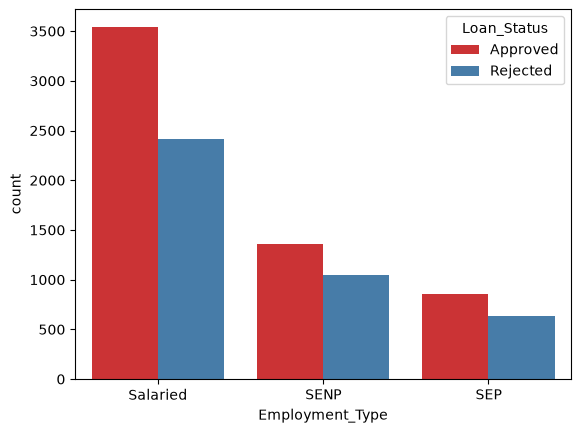

In [15]:
print('Number of people who take loan as group by employment type:')
print(df['Employment_Type'].value_counts())
sns.countplot(x='Employment_Type', hue='Loan_Status', data=df, palette='Set1')
plt.show()

Number of people who take loan as group by loan type:
Loan_Type
Personal    3164
Home        2757
Vehicle     2311
Business    1615
Name: count, dtype: int64


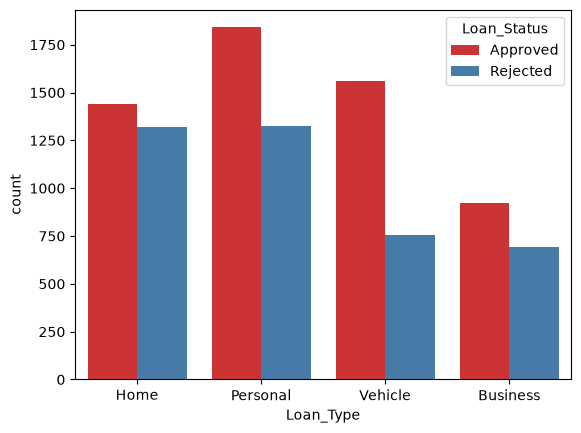

In [16]:
print('Number of people who take loan as group by loan type:')
print(df['Loan_Type'].value_counts())
sns.countplot(x='Loan_Type', hue='Loan_Status', data=df, palette='Set1')
plt.show()

Number of people who take loan as group by CIBIL band:
CIBIL_Band
650-749          4372
750+             3937
<650              940
New to credit     598
Name: count, dtype: int64


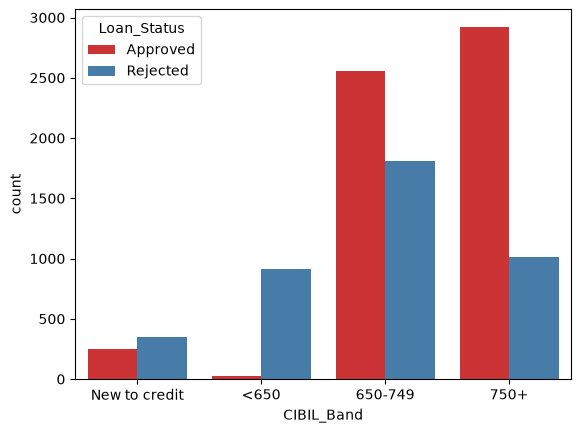

In [17]:
# Equivalent of the video's Credit_History: bureau score band (-1 = new to credit, no history)
df['CIBIL_Band'] = pd.cut(df['CIBIL_Score'], bins=[-2, 0, 649, 749, 900],
                          labels=['New to credit', '<650', '650-749', '750+'])
print('Number of people who take loan as group by CIBIL band:')
print(df['CIBIL_Band'].value_counts())
sns.countplot(x='CIBIL_Band', hue='Loan_Status', data=df, palette='Set1')
plt.show()

## 9. Select features (X) and target (y)

**Change from video:**
- Columns are selected by name rather than `iloc` positions, so the selection can't silently break if the column order changes.
- `Gender` and `Marital_Status` are excluded from X.
- `Loan_ID` is an identifier, not a feature.

In [18]:
feature_cols = ['Age', 'Dependents', 'Employment_Type', 'Work_Experience', 'Existing_EMI',
                'CIBIL_Score', 'Loan_Type', 'Loan_Tenure', 'Collateral_Value', 'Property_Area',
                'Loan_Amount_log', 'Total_Income_log']
X = df[feature_cols]
y = df['Loan_Status']
X.head()

,Age,Dependents,Employment_Type,Work_Experience,Existing_EMI,CIBIL_Score,Loan_Type,Loan_Tenure,Collateral_Value,Property_Area,Loan_Amount_log,Total_Income_log
0,40.0,0.0,Salaried,18.0,1900.0,821.0,Home,240.0,2080000.0,Rural,14.180154,10.732039
1,46.0,2.0,SENP,19.0,0.0,748.0,Personal,36.0,0.0,Semi-Urban,12.542545,10.555813
2,24.0,0.0,Salaried,4.0,0.0,851.0,Home,240.0,3710000.0,Rural,14.805052,11.050890
3,34.0,0.0,SENP,10.0,0.0,747.0,Home,240.0,2940000.0,Urban,14.594835,10.839581
4,23.0,0.0,Salaried,0.0,0.0,801.0,Personal,36.0,0.0,Semi-Urban,13.038982,10.680516


In [19]:
y.head()

0    Approved
1    Approved
2    Approved
3    Approved
4    Rejected
Name: Loan_Status, dtype: str

## 10. Train/test split

In [20]:
from sklearn.model_selection import train_test_split

# Change from video: stratify=y keeps the same Approved/Rejected ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_train, X_test = X_train.copy(), X_test.copy()
print(X_train.shape, X_test.shape)

(7877, 12) (1970, 12)


## 11. Label encoding

**Change from video:** the video called `fit_transform` on the test set as well. That builds a new mapping from the test data, so `'Home'` could be 1 in train and 2 in test. The encoder is now fitted on train only, and the test set only goes through `transform`.

In [21]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Employment_Type', 'Loan_Type', 'Property_Area']
for col in cat_cols:
    labelencoder_X = LabelEncoder()
    X_train[col] = labelencoder_X.fit_transform(X_train[col])
    X_test[col] = labelencoder_X.transform(X_test[col])
    print(col, dict(zip(labelencoder_X.classes_, range(len(labelencoder_X.classes_)))))

X_train.head()

Employment_Type {'SENP': 0, 'SEP': 1, 'Salaried': 2}
Loan_Type {'Business': 0, 'Home': 1, 'Personal': 2, 'Vehicle': 3}
Property_Area {'Rural': 0, 'Semi-Urban': 1, 'Urban': 2}


,Age,Dependents,Employment_Type,Work_Experience,Existing_EMI,CIBIL_Score,Loan_Type,Loan_Tenure,Collateral_Value,Property_Area,Loan_Amount_log,Total_Income_log
1883,46.0,0.0,0,23.0,11100.0,627.0,3,48.0,900000.0,1,13.473020,11.069758
8792,27.0,0.0,2,2.0,4100.0,690.0,2,60.0,0.0,2,12.429216,11.134589
8371,21.0,0.0,0,0.0,0.0,738.0,0,84.0,520000.0,2,12.847927,11.416415
8956,29.0,2.0,2,4.0,0.0,787.0,1,300.0,5540000.0,2,14.956544,11.621780
5428,37.0,3.0,0,14.0,0.0,630.0,3,24.0,100000.0,0,11.156251,11.744831


In [22]:
# LabelEncoder sorts alphabetically, so Approved -> 0 and Rejected -> 1. That is the opposite of the
# video (N -> 0, Y -> 1), so the target is mapped explicitly instead: 1 = loan approved
y_train = (y_train == 'Approved').astype(int).values
y_test = (y_test == 'Approved').astype(int).values
y_train[:10]

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

## 12. Standard scaling

In [23]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)     # change from video: transform only, never fit on test
X_train[:3]

array([[ 0.96718747, -1.26099006, -1.59886083,  1.13804105,  0.40876649,
        -0.33112196,  1.34698978, -0.51478859, -0.27731888, -0.37890741,
        -0.00574285, -0.07812081],
       [-1.20314026, -1.26099006,  0.75476032, -1.37278023, -0.13991009,
         0.00428235,  0.36200663, -0.37690598, -0.52252238,  0.89876968,
        -0.85842067,  0.01348366],
       [-1.88850691, -1.26099006, -1.59886083, -1.61190606, -0.4612778 ,
         0.2598285 , -1.60795968, -0.10114076, -0.38084925,  0.89876968,
        -0.51637849,  0.41169846]])

## 13. Random Forest classifier

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
print('Accuracy of Random Forest is', metrics.accuracy_score(y_test, y_pred))
y_pred

Accuracy of Random Forest is 0.8401015228426396


array([1, 0, 0, ..., 1, 1, 0], shape=(1970,))

## 14. Naive Bayes (Gaussian)

In [25]:
from sklearn.naive_bayes import GaussianNB

nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

y_pred = nb_clf.predict(X_test)
print('Accuracy of Gaussian Naive Bayes is', metrics.accuracy_score(y_test, y_pred))
y_pred

Accuracy of Gaussian Naive Bayes is 0.6873096446700507


array([1, 0, 0, ..., 1, 1, 0], shape=(1970,))

## 15. Decision Tree classifier

In [26]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=0)
dt_clf.fit(X_train, y_train)

y_pred = dt_clf.predict(X_test)
print('Accuracy of Decision Tree is', metrics.accuracy_score(y_test, y_pred))
y_pred

Accuracy of Decision Tree is 0.7746192893401015


array([0, 0, 0, ..., 1, 1, 1], shape=(1970,))

## 16. K-Nearest Neighbors classifier

In [27]:
from sklearn.neighbors import KNeighborsClassifier

kn_clf = KNeighborsClassifier()
kn_clf.fit(X_train, y_train)

y_pred = kn_clf.predict(X_test)
print('Accuracy of KNN is', metrics.accuracy_score(y_test, y_pred))
y_pred

Accuracy of KNN is 0.7263959390862944


array([1, 0, 0, ..., 1, 1, 1], shape=(1970,))

## 17. Which classifier is best?

The video picked its model on accuracy alone. ROC-AUC and F1 are added here because the classes are mildly imbalanced (58.5 / 41.5).

In [28]:
models = {'Random Forest': rf_clf, 'Naive Bayes': nb_clf, 'Decision Tree': dt_clf, 'KNN': kn_clf}
rows = []
for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({'Model': name,
                 'Accuracy': metrics.accuracy_score(y_test, pred),
                 'ROC-AUC': metrics.roc_auc_score(y_test, proba),
                 'F1': metrics.f1_score(y_test, pred)})
results = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).round(3)
print('Best model:', results.iloc[0]['Model'])
results

Best model: Random Forest


,Model,Accuracy,ROC-AUC,F1
0,Random Forest,0.840,0.909,0.867
2,Decision Tree,0.775,0.771,0.805
3,KNN,0.726,0.764,0.785
1,Naive Bayes,0.687,0.726,0.761


In [29]:
best = models[results.iloc[0]['Model']]
print(metrics.classification_report(y_test, best.predict(X_test), target_names=['Rejected', 'Approved']))

              precision    recall  f1-score   support

    Rejected       0.84      0.76      0.80       818
    Approved       0.84      0.89      0.87      1152

    accuracy                           0.84      1970
   macro avg       0.84      0.83      0.83      1970
weighted avg       0.84      0.84      0.84      1970



## 18. Bonus: the same four models on the report's engineered dataset

`loan_applications_final.csv` is the fully preprocessed output from `report.md`, with FOIR, collateral coverage, loan-to-income and age at maturity. Running the same four classifiers on it shows how much feature engineering adds over the video's approach.

In [30]:
final = pd.read_csv('loan_applications_final.csv')
Xf = final.drop(columns=['loan_id', 'loan_status'])   # loan_id is an identifier: drop before fit
yf = final['loan_status']
Xf_train, Xf_test, yf_train, yf_test = train_test_split(Xf, yf, test_size=0.2, random_state=0, stratify=yf)

rows = []
for name, model in {'Random Forest': RandomForestClassifier(random_state=0), 'Naive Bayes': GaussianNB(),
                    'Decision Tree': DecisionTreeClassifier(random_state=0),
                    'KNN': KNeighborsClassifier()}.items():
    model.fit(Xf_train, yf_train)
    rows.append({'Model': name, 'Accuracy (engineered)': metrics.accuracy_score(yf_test, model.predict(Xf_test))})
pd.DataFrame(rows).merge(results[['Model', 'Accuracy']].rename(columns={'Accuracy': 'Accuracy (video approach)'}),
                         on='Model').round(3)

,Model,Accuracy (engineered),Accuracy (video approach)
0,Random Forest,0.878,0.840
1,Naive Bayes,0.771,0.687
2,Decision Tree,0.827,0.775
3,KNN,0.820,0.726
